# Descriptive Statistics: Ghanaian Mobile Money Credit Risk Data

Systematic statistical summary of the synthetic MoMo dataset — numerical and categorical features, variability, distributions, and per-archetype breakdowns.

In [1]:
import sys, os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(project_root, 'src'))
from seqcredit_model.config import (
    DATA_DIR, TRANSACTIONS_DIR, USER_FEATURES_FILE, USER_LABELS_FILE,
    SYNTHETIC_PARAMS_FILE
)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

ARCHETYPE_COLORS = {
    'non_borrower': '#95a5a6',
    'responsible_borrower': '#2ecc71',
    'occasional_borrower': '#3498db',
    'risky_borrower': '#f39c12',
    'defaulter': '#e74c3c',
}
ARCHETYPE_ORDER = [
    'non_borrower', 'responsible_borrower', 'occasional_borrower',
    'risky_borrower', 'defaulter'
]
ARCHETYPE_LABELS = {a: a.replace('_', ' ').title() for a in ARCHETYPE_ORDER}
RISK_COLORS = {-1: '#95a5a6', 0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
RISK_LABELS = {-1: 'No Loans', 0: 'Good', 1: 'Late', 2: 'Default'}

print(f'Data directory: {DATA_DIR}')

Data directory: C:\Users\Dell\Projects\seqcredit-model\data


In [2]:
labels = pd.read_csv(str(USER_LABELS_FILE))
features = pd.read_csv(str(USER_FEATURES_FILE))
with open(str(SYNTHETIC_PARAMS_FILE)) as f:
    calibration = json.load(f)

users = features.merge(labels, on='user_id', how='inner')

n_txn_files = len(list(TRANSACTIONS_DIR.glob('USER_*.csv')))
print(f'Users:             {len(users):,}')
print(f'Feature columns:   {features.shape[1] - 1}')
print(f'Label columns:     {labels.shape[1] - 1}')
print(f'Transaction files: {n_txn_files:,}')

Users:             10,000
Feature columns:   29
Label columns:     5
Transaction files: 10,000


In [3]:
# Stratified sample of per-user transaction CSVs
np.random.seed(42)
SAMPLE_SIZE = 500

sample_ids = []
for archetype in ARCHETYPE_ORDER:
    arch_users = labels[labels['credit_archetype'] == archetype]['user_id'].values
    n_draw = max(10, int(SAMPLE_SIZE * len(arch_users) / len(labels)))
    drawn = np.random.choice(arch_users, size=min(n_draw, len(arch_users)), replace=False)
    sample_ids.extend(drawn)

txn_frames = []
for uid in sample_ids:
    fpath = TRANSACTIONS_DIR / f'{uid}.csv'
    if fpath.exists():
        df = pd.read_csv(str(fpath))
        df['user_id'] = uid
        txn_frames.append(df)

txns = pd.concat(txn_frames, ignore_index=True)
txns['TRANSACTION DATE'] = pd.to_datetime(txns['TRANSACTION DATE'])
txns = txns.merge(labels[['user_id', 'credit_archetype', 'credit_risk_label']], on='user_id')
txns['hour'] = txns['TRANSACTION DATE'].dt.hour
txns['day_of_week'] = txns['TRANSACTION DATE'].dt.day_name()

print(f'Sampled {len(set(sample_ids))} users -> {len(txns):,} transactions')
print(f'Date range: {txns["TRANSACTION DATE"].min().date()} to {txns["TRANSACTION DATE"].max().date()}')

Sampled 498 users -> 51,556 transactions
Date range: 2024-01-01 to 2024-06-27


---
## Section 1: Dataset Overview

In [4]:
feature_cols = [c for c in features.columns if c != 'user_id']
num_cols = features[feature_cols].select_dtypes(include=np.number).columns.tolist()

print('=== USER FEATURES (user_features.csv) ===')
print(f'Shape: {features.shape[0]:,} rows x {features.shape[1]} columns')
print(f'Numeric feature columns: {len(num_cols)}')
print(f'Missing values: {features[num_cols].isnull().sum().sum()}')

print('\n=== USER LABELS (user_labels.csv) ===')
print(f'Shape: {labels.shape[0]:,} rows x {labels.shape[1]} columns')
print(f'Columns: {list(labels.columns)}')

print('\n=== SAMPLED TRANSACTION DATA ===')
print(f'Shape: {len(txns):,} rows x {txns.shape[1]} columns')
print(f'Columns: {list(txns.columns)}')

print('\n=== NUMERIC FEATURE COLUMNS ===')
for i, col in enumerate(num_cols, 1):
    print(f'  {i:2d}. {col}')

=== USER FEATURES (user_features.csv) ===
Shape: 10,000 rows x 30 columns
Numeric feature columns: 29
Missing values: 0

=== USER LABELS (user_labels.csv) ===
Shape: 10,000 rows x 6 columns
Columns: ['user_id', 'credit_archetype', 'loans_taken', 'credit_risk_label', 'final_credit_limit', 'gen_txn_count']

=== SAMPLED TRANSACTION DATA ===
Shape: 51,556 rows x 24 columns
Columns: ['TRANSACTION DATE', 'FROM ACCT', 'FROM NAME', 'FROM NO.', 'TRANS. TYPE', 'AMOUNT', 'FEES', 'E-LEVY', 'BAL BEFORE', 'BAL AFTER', 'TO NO.', 'TO NAME', 'TO ACCT', 'user_id', 'LOAN_PROVIDER', 'LOAN_PRINCIPAL', 'LOAN_INTEREST_RATE', 'LOAN_DUE_DATE', 'LOAN_PRINCIPAL_PAID', 'LOAN_INTEREST_PAID', 'credit_archetype', 'credit_risk_label', 'hour', 'day_of_week']

=== NUMERIC FEATURE COLUMNS ===
   1. obs_txn_count
   2. total_volume
   3. avg_transaction_amount
   4. median_transaction_amount
   5. std_transaction_amount
   6. max_transaction_amount
   7. min_transaction_amount
   8. cv_transaction_amount
   9. pct_transf

---
## Section 2: Numerical Feature Statistics

Full descriptive statistics for all numeric user-level features. CV (coefficient of variation = std/mean) measures relative variability — higher CV means more spread relative to the mean.

In [5]:
stats = features[num_cols].describe().T
stats.insert(3, 'cv', (stats['std'] / stats['mean'].abs()).round(4))
stats.columns = ['Count', 'Mean', 'Std Dev', 'CV', 'Min', 'P25', 'Median', 'P75', 'Max']
stats = stats.round(4)

try:
    styled = (
        stats.style
        .format('{:.4f}')
        .background_gradient(subset=['CV'], cmap='YlOrRd')
        .background_gradient(subset=['Std Dev'], cmap='Blues')
    )
    display(styled)
except Exception:
    display(stats)

,Count,Mean,Std Dev,CV,Min,P25,Median,P75,Max
obs_txn_count,10000.0000,103.2344,10.2844,0.0996,69.0000,96.0000,103.0000,110.0000,144.0000
total_volume,10000.0000,3300.4421,681.3572,0.2064,1284.0057,2825.2658,3260.2021,3735.3927,6225.5271
avg_transaction_amount,10000.0000,31.9613,5.7443,0.1797,15.1082,27.9687,31.7229,35.5876,55.4049
median_transaction_amount,10000.0000,15.8322,4.2164,0.2663,6.0900,12.7950,15.2550,18.3600,37.3500
std_transaction_amount,10000.0000,41.5502,5.2325,0.1259,22.8861,38.2223,41.4583,44.6980,140.8670
max_transaction_amount,10000.0000,192.7288,32.0569,0.1663,112.8257,184.1365,192.0636,197.0992,1362.2600
min_transaction_amount,10000.0000,0.6617,0.5767,0.8715,0.0000,0.1282,0.5800,1.0000,4.0700
cv_transaction_amount,10000.0000,1.3191,0.1450,0.1099,0.9288,1.2169,1.3089,1.4078,2.5446
pct_transfers,10000.0000,0.4455,0.0712,0.1598,0.1696,0.3968,0.4457,0.4949,0.6837
pct_debits,10000.0000,0.2318,0.0596,0.2569,0.0426,0.1900,0.2294,0.2718,0.4615


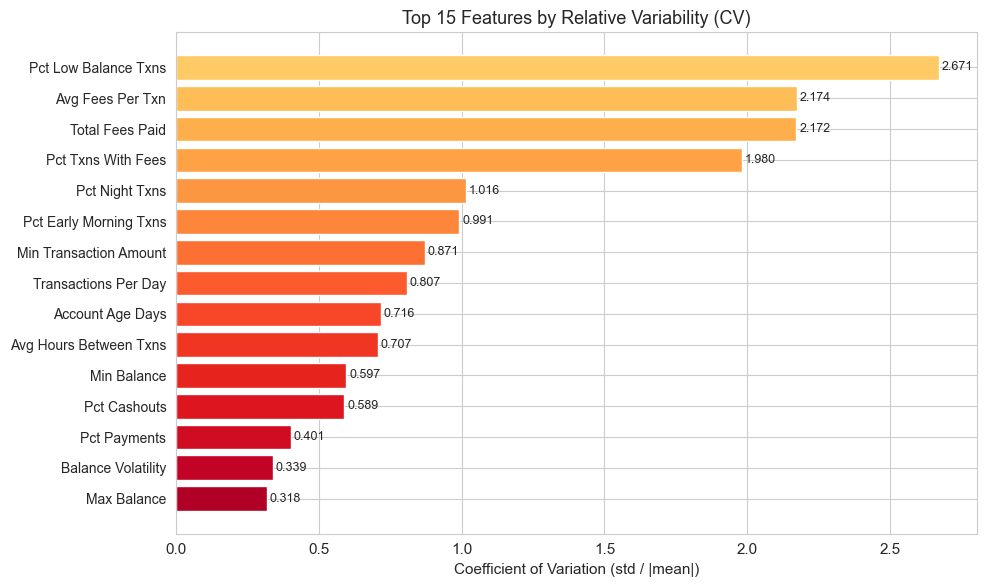


Bottom 5 (least variable):
unique_recipients         0.1429
unique_txn_types          0.1391
std_transaction_amount    0.1259
cv_transaction_amount     0.1099
obs_txn_count             0.0996


In [6]:
# Top 15 features by coefficient of variation (most variable features)
cv_series = (features[num_cols].std() / features[num_cols].mean().abs()).sort_values(ascending=False)
top_cv = cv_series.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_cv)), top_cv.values,
               color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_cv))), edgecolor='white')
ax.set_yticks(range(len(top_cv)))
ax.set_yticklabels([f.replace('_', ' ').title() for f in top_cv.index], fontsize=10)
ax.invert_yaxis()
for i, v in enumerate(top_cv.values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Coefficient of Variation (std / |mean|)')
ax.set_title('Top 15 Features by Relative Variability (CV)')
plt.tight_layout()
plt.show()

print('\nBottom 5 (least variable):')
print(cv_series.tail(5).round(4).to_string())

### 2.1 Numerical Distributions by Archetype

Violin plots show the full distribution shape (median, IQR, tails) for key features across the five user archetypes.

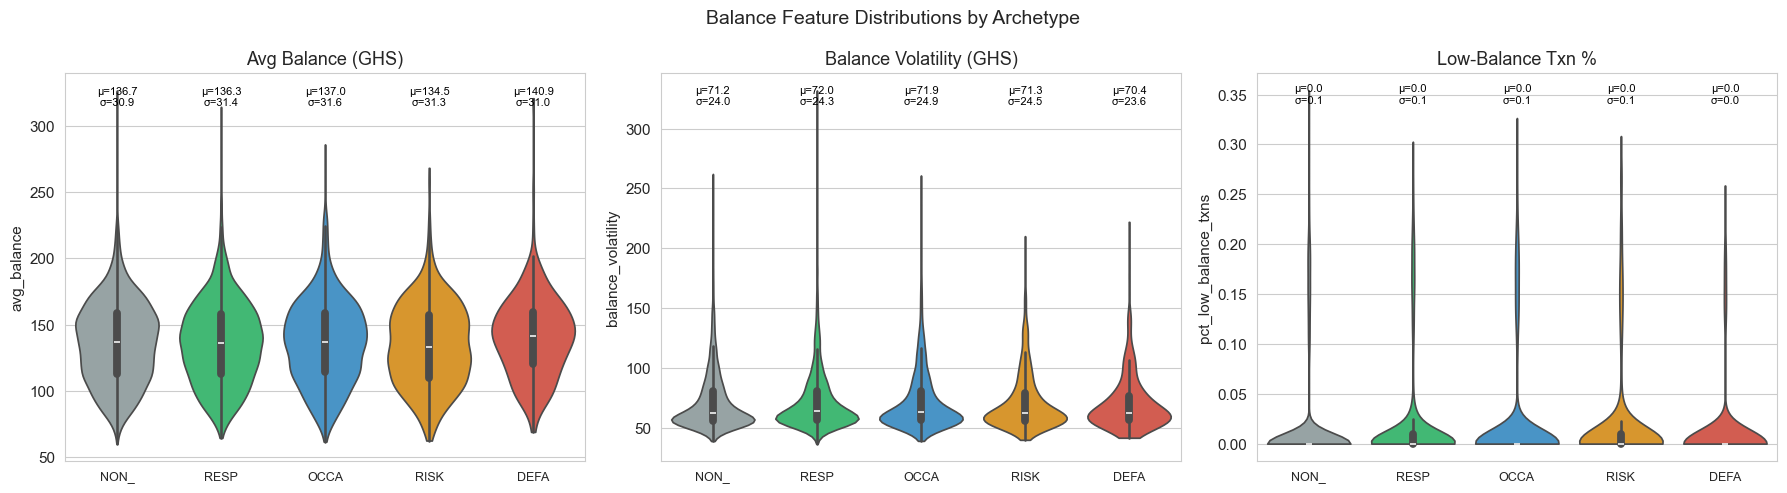

In [7]:
palette = [ARCHETYPE_COLORS[a] for a in ARCHETYPE_ORDER]
xlabels = [ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (col, title), ax in zip([
    ('avg_balance', 'Avg Balance (GHS)'),
    ('balance_volatility', 'Balance Volatility (GHS)'),
    ('pct_low_balance_txns', 'Low-Balance Txn %'),
], axes):
    sns.violinplot(data=users, x='credit_archetype', y=col,
                   order=ARCHETYPE_ORDER, palette=palette, inner='box', ax=ax, cut=0)
    ax.set_xticklabels([a[:4].upper() for a in ARCHETYPE_ORDER], fontsize=9)
    ax.set_xlabel('')
    ax.set_title(title)
    for i, arch in enumerate(ARCHETYPE_ORDER):
        m = users[users['credit_archetype'] == arch][col].mean()
        s = users[users['credit_archetype'] == arch][col].std()
        ax.text(i, ax.get_ylim()[1] * 0.97, f'μ={m:.1f}\nσ={s:.1f}',
                ha='center', va='top', fontsize=8, color='black')
plt.suptitle('Balance Feature Distributions by Archetype', fontsize=14)
plt.tight_layout()
plt.show()

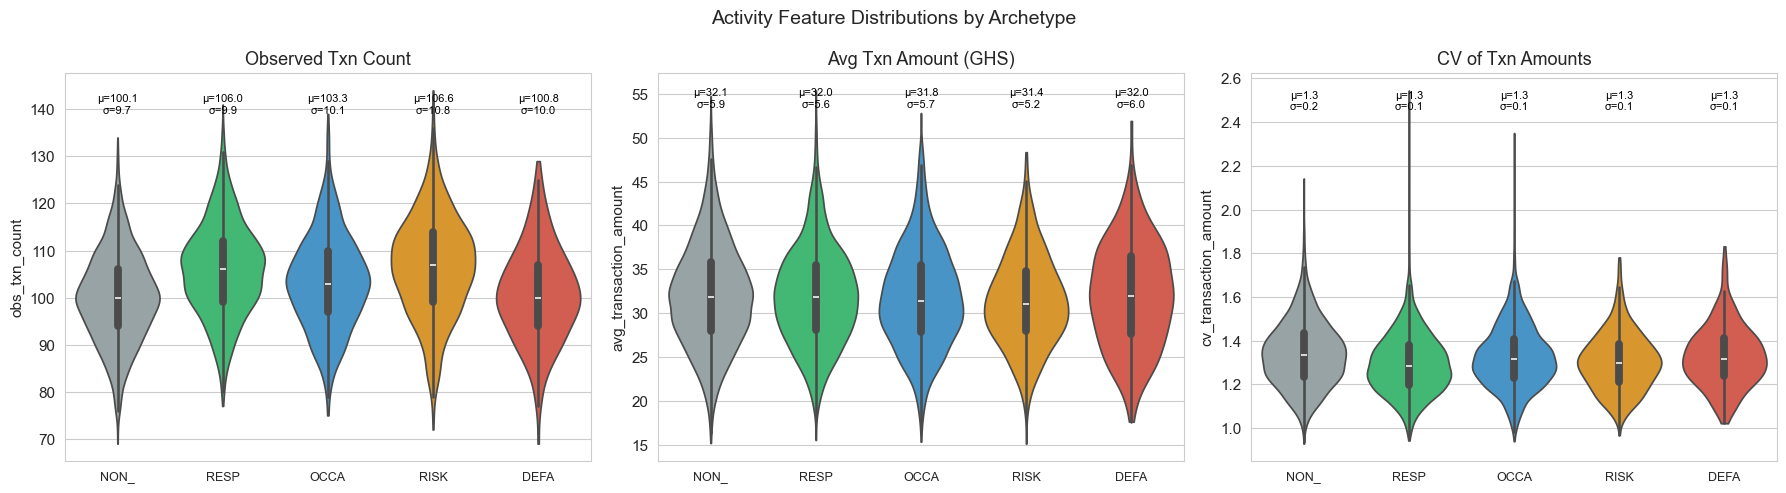

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (col, title), ax in zip([
    ('obs_txn_count', 'Observed Txn Count'),
    ('avg_transaction_amount', 'Avg Txn Amount (GHS)'),
    ('cv_transaction_amount', 'CV of Txn Amounts'),
], axes):
    sns.violinplot(data=users, x='credit_archetype', y=col,
                   order=ARCHETYPE_ORDER, palette=palette, inner='box', ax=ax, cut=0)
    ax.set_xticklabels([a[:4].upper() for a in ARCHETYPE_ORDER], fontsize=9)
    ax.set_xlabel('')
    ax.set_title(title)
    for i, arch in enumerate(ARCHETYPE_ORDER):
        m = users[users['credit_archetype'] == arch][col].mean()
        s = users[users['credit_archetype'] == arch][col].std()
        ax.text(i, ax.get_ylim()[1] * 0.97, f'μ={m:.1f}\nσ={s:.1f}',
                ha='center', va='top', fontsize=8, color='black')
plt.suptitle('Activity Feature Distributions by Archetype', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 3: Categorical Feature Statistics

### 3.1 User-Level Categorical Variables

In [10]:
# credit_archetype frequency table
print('--- credit_archetype ---')
print(f'Unique values: {labels["credit_archetype"].nunique()}\n')
arch_vc = labels['credit_archetype'].value_counts().reindex(ARCHETYPE_ORDER)
arch_table = pd.DataFrame({
    'Count': arch_vc,
    'Percentage (%)': (arch_vc / len(labels) * 100).round(2)
})
display(arch_table)

# credit_risk_label frequency table
print('\n--- credit_risk_label ---')
print(f'Unique values: {labels["credit_risk_label"].nunique()}\n')
risk_vc = labels['credit_risk_label'].value_counts().sort_index()
risk_table = pd.DataFrame({
    'Label Name': [RISK_LABELS[k] for k in risk_vc.index],
    'Count': risk_vc.values,
    'Percentage (%)': (risk_vc.values / len(labels) * 100).round(2)
}, index=risk_vc.index)
display(risk_table)

# Binary target among borrowers
borrowers = labels[labels['credit_risk_label'] != -1]
defaulters = (borrowers['credit_risk_label'] == 2).sum()
print(f'\nBorrowers only (N={len(borrowers):,}): {defaulters:,} defaulters ({defaulters/len(borrowers)*100:.1f}%)')

--- credit_archetype ---
Unique values: 5



,Count,Percentage (%)
credit_archetype,,
non_borrower,3916,39.16
responsible_borrower,3506,35.06
occasional_borrower,1480,14.80
risky_borrower,871,8.71
defaulter,227,2.27



--- credit_risk_label ---
Unique values: 4



,Label Name,Count,Percentage (%)
credit_risk_label,,,
-1,No Loans,3916,39.16
0,Good,3315,33.15
1,Late,2007,20.07
2,Default,762,7.62



Borrowers only (N=6,084): 762 defaulters (12.5%)


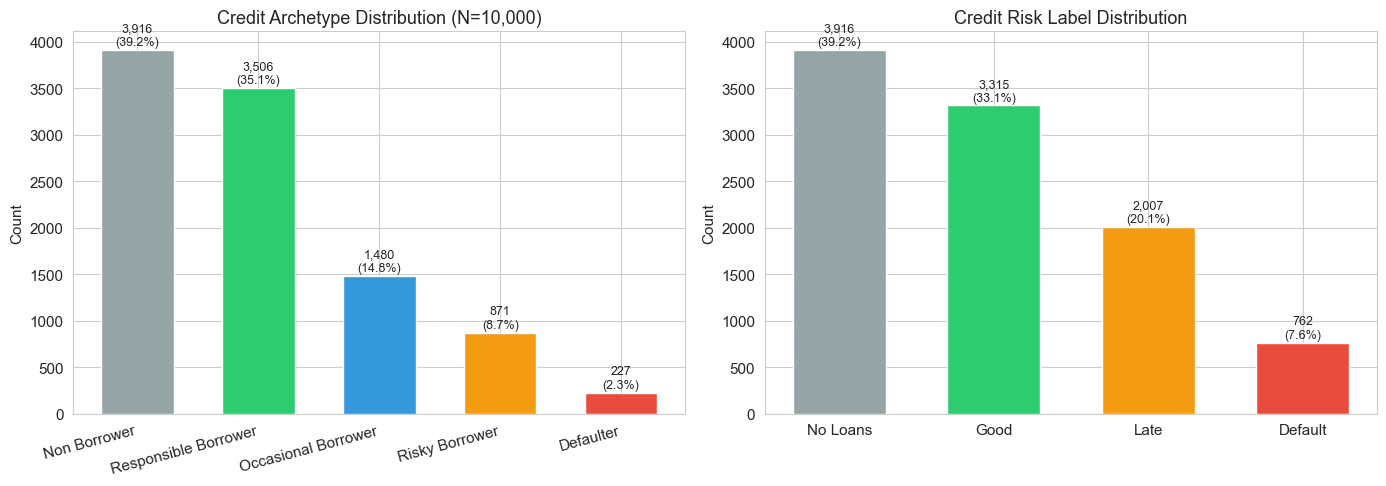

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [ARCHETYPE_COLORS[a] for a in ARCHETYPE_ORDER]

# Archetype bar chart
bars = ax1.bar(range(len(arch_vc)), arch_vc.values, color=colors, edgecolor='white', width=0.6)
ax1.set_xticks(range(len(arch_vc)))
ax1.set_xticklabels([ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER], rotation=15, ha='right')
for bar, v in zip(bars, arch_vc.values):
    pct = v / len(labels) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, v + 50, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)
ax1.set_ylabel('Count')
ax1.set_title(f'Credit Archetype Distribution (N={len(labels):,})')

# Risk label bar chart
risk_colors = [RISK_COLORS[k] for k in risk_vc.index]
bars2 = ax2.bar([RISK_LABELS[k] for k in risk_vc.index], risk_vc.values,
                color=risk_colors, edgecolor='white', width=0.6)
for bar, v in zip(bars2, risk_vc.values):
    pct = v / len(labels) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, v + 50, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)
ax2.set_ylabel('Count')
ax2.set_title('Credit Risk Label Distribution')

plt.tight_layout()
plt.show()

### 3.2 Transaction-Level Categorical Variables

*(Based on the stratified sample of 500 users.)*

In [12]:
# Transaction type frequency table
print('--- TRANS. TYPE ---')
print(f'Unique values: {txns["TRANS. TYPE"].nunique()}\n')
type_vc = txns['TRANS. TYPE'].value_counts()
type_table = pd.DataFrame({
    'Count': type_vc,
    'Percentage (%)': (type_vc / len(txns) * 100).round(2)
})
display(type_table)

# Loan provider frequency table (CREDIT rows only)
credit_txns = txns[txns['TRANS. TYPE'] == 'CREDIT']
if 'LOAN_PROVIDER' in credit_txns.columns and len(credit_txns) > 0:
    print(f'\n--- LOAN_PROVIDER (loan disbursements only, N={len(credit_txns):,}) ---')
    print(f'Unique values: {credit_txns["LOAN_PROVIDER"].nunique()}\n')
    prov_vc = credit_txns['LOAN_PROVIDER'].value_counts()
    prov_table = pd.DataFrame({
        'Count': prov_vc,
        'Percentage (%)': (prov_vc / len(credit_txns) * 100).round(2)
    })
    display(prov_table)

--- TRANS. TYPE ---
Unique values: 8



,Count,Percentage (%)
TRANS. TYPE,,
TRANSFER,22981,44.57
DEBIT,11851,22.99
CASH_IN,6425,12.46
PAYMENT,3328,6.46
PAYMENT_SEND,3235,6.27
CASH_OUT,2199,4.27
CREDIT,787,1.53
LOAN_REPAYMENT,750,1.45



--- LOAN_PROVIDER (loan disbursements only, N=787) ---
Unique values: 5



,Count,Percentage (%)
LOAN_PROVIDER,,
XPRESSLOAN,174,22.11
QWIKLOAN,166,21.09
XTRACASH,163,20.71
CEDISPAY,158,20.08
FIDO,126,16.01


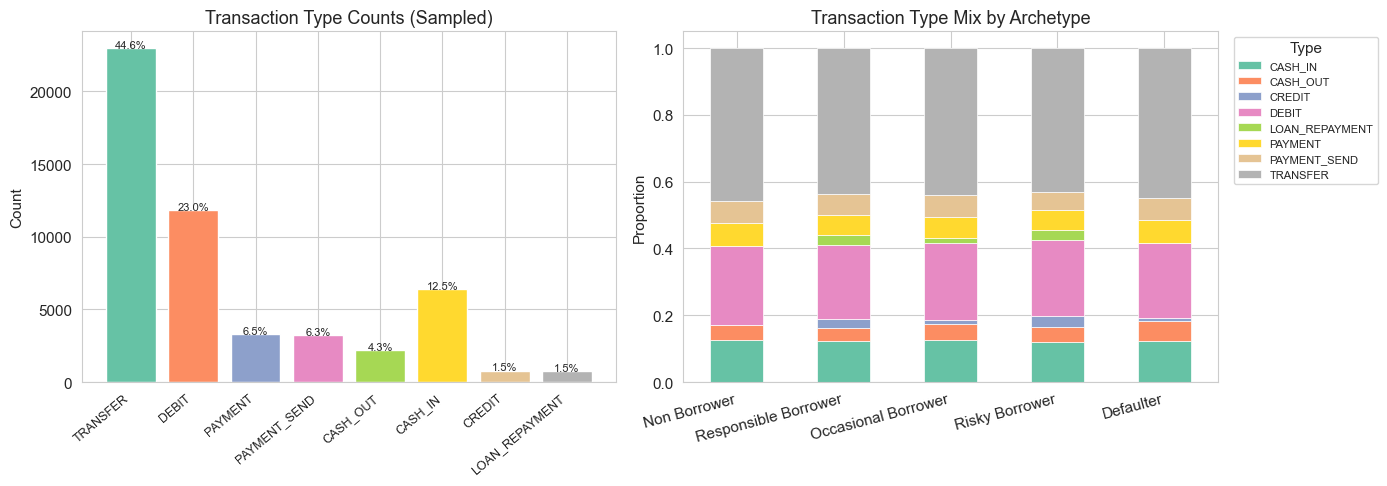

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction type bar chart
txn_type_order = ['TRANSFER', 'DEBIT', 'PAYMENT', 'PAYMENT_SEND',
                  'CASH_OUT', 'CASH_IN', 'ADJUSTMENT', 'CREDIT', 'LOAN_REPAYMENT']
present_types = [t for t in txn_type_order if t in type_vc.index]
type_vc_ordered = type_vc.reindex(present_types).dropna()
bars = axes[0].bar(range(len(type_vc_ordered)), type_vc_ordered.values,
                   color=sns.color_palette('Set2', len(type_vc_ordered)), edgecolor='white')
axes[0].set_xticks(range(len(type_vc_ordered)))
axes[0].set_xticklabels(type_vc_ordered.index, rotation=40, ha='right', fontsize=9)
for bar, v in zip(bars, type_vc_ordered.values):
    pct = v / len(txns) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10, f'{pct:.1f}%', ha='center', fontsize=8)
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Type Counts (Sampled)')

# Transaction type mix by archetype (stacked proportions)
type_props = txns.groupby(['credit_archetype', 'TRANS. TYPE']).size().unstack(fill_value=0)
type_props = type_props.div(type_props.sum(axis=1), axis=0)
type_props = type_props.reindex(ARCHETYPE_ORDER)
type_props.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white', linewidth=0.5)
axes[1].set_xticklabels([ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER], rotation=15, ha='right')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Transaction Type Mix by Archetype')
axes[1].legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 3.3 Temporal Categorical Variables

In [14]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Day-of-week frequency table
print('--- Day of Week ---')
dow_vc = txns['day_of_week'].value_counts().reindex(dow_order)
dow_table = pd.DataFrame({
    'Count': dow_vc,
    'Percentage (%)': (dow_vc / len(txns) * 100).round(2)
})
display(dow_table)

# Hour bucket frequency table
print('\n--- Hour of Day (0-23) ---')
hour_vc = txns['hour'].value_counts().sort_index()
hour_table = pd.DataFrame({
    'Count': hour_vc,
    'Percentage (%)': (hour_vc / len(txns) * 100).round(2)
})
display(hour_table)

--- Day of Week ---


,Count,Percentage (%)
day_of_week,,
Monday,7260,14.08
Tuesday,7122,13.81
Wednesday,7277,14.11
Thursday,7377,14.31
Friday,7110,13.79
Saturday,7678,14.89
Sunday,7732,15.00



--- Hour of Day (0-23) ---


,Count,Percentage (%)
hour,,
0,769,1.49
1,791,1.53
2,741,1.44
3,778,1.51
6,2597,5.04
7,1582,3.07
8,2018,3.91
9,2581,5.01
10,2816,5.46


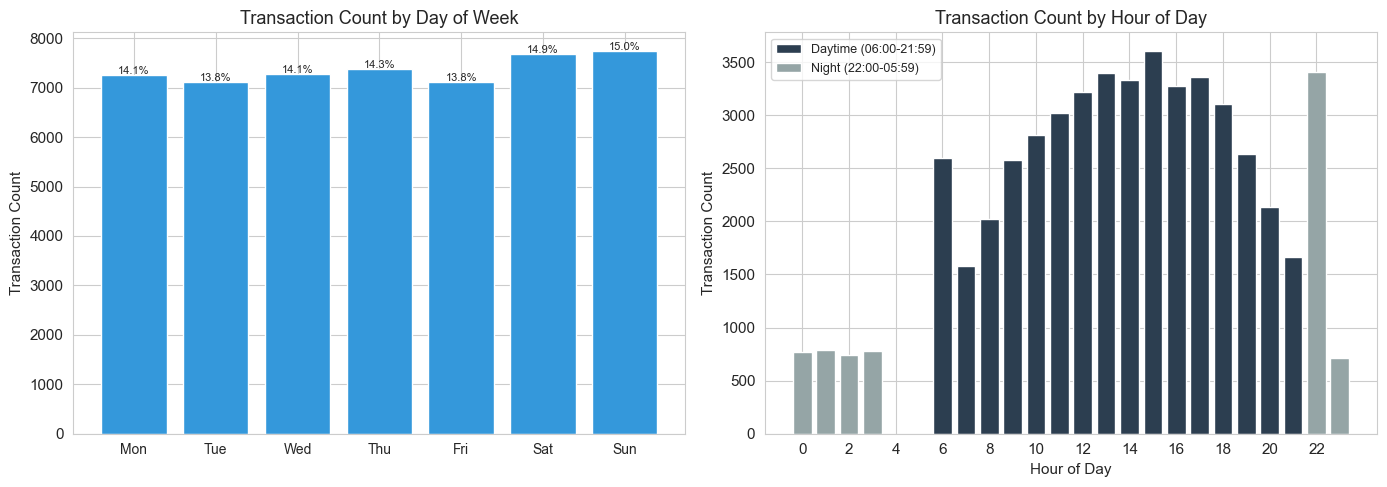

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Day-of-week bar chart
bars = ax1.bar(range(7), dow_vc.values, color='#3498db', edgecolor='white')
ax1.set_xticks(range(7))
ax1.set_xticklabels([d[:3] for d in dow_order], fontsize=10)
for bar, v in zip(bars, dow_vc.values):
    pct = v / len(txns) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, v + 20, f'{pct:.1f}%', ha='center', fontsize=8)
ax1.set_ylabel('Transaction Count')
ax1.set_title('Transaction Count by Day of Week')

# Hour-of-day bar chart
hour_colors = ['#2c3e50' if 6 <= h < 22 else '#95a5a6' for h in hour_vc.index]
ax2.bar(hour_vc.index, hour_vc.values, color=hour_colors, edgecolor='white', width=0.8)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Transaction Count')
ax2.set_title('Transaction Count by Hour of Day')
ax2.set_xticks(range(0, 24, 2))
legend_elements = [
    mpatches.Patch(facecolor='#2c3e50', label='Daytime (06:00-21:59)'),
    mpatches.Patch(facecolor='#95a5a6', label='Night (22:00-05:59)'),
]
ax2.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 4: Key Numerical Distributions

Distribution plots for transaction amounts and loan-specific data.

--- AMOUNT (all transaction types) ---
count    51189.00
mean        32.25
std         42.15
min          0.50
25%          6.85
50%         15.41
75%         35.83
max        456.46
CV:      1.3071
Skew:    2.2267
Kurt:    4.7892


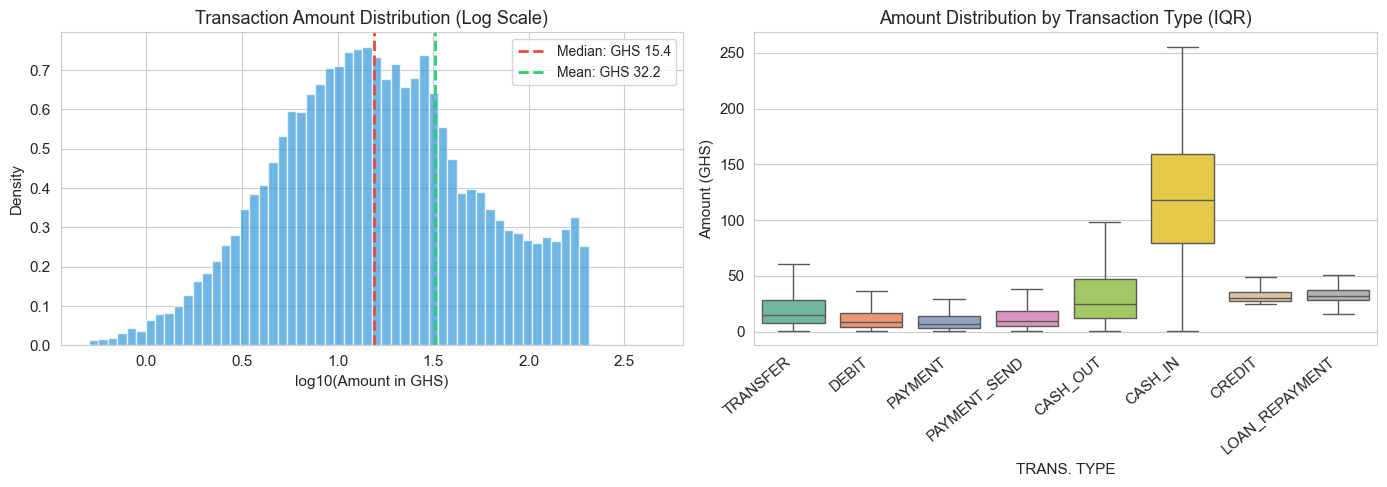

In [16]:
amounts = txns['AMOUNT'][txns['AMOUNT'] > 0.5]

print('--- AMOUNT (all transaction types) ---')
print(amounts.describe().round(2).to_string())
print(f'CV:      {amounts.std() / amounts.mean():.4f}')
print(f'Skew:    {amounts.skew():.4f}')
print(f'Kurt:    {amounts.kurt():.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
ax1.hist(np.log10(amounts), bins=60, density=True, alpha=0.7, color='#3498db', edgecolor='white')
ax1.set_xlabel('log10(Amount in GHS)')
ax1.set_ylabel('Density')
ax1.set_title('Transaction Amount Distribution (Log Scale)')
ax1.axvline(np.log10(amounts.median()), color='#e74c3c', linestyle='--', linewidth=2,
            label=f'Median: GHS {amounts.median():.1f}')
ax1.axvline(np.log10(amounts.mean()), color='#2ecc71', linestyle='--', linewidth=2,
            label=f'Mean: GHS {amounts.mean():.1f}')
ax1.legend(fontsize=10)

# Box plots by transaction type
txn_type_order_plot = ['TRANSFER', 'DEBIT', 'PAYMENT', 'PAYMENT_SEND',
                        'CASH_OUT', 'CASH_IN', 'CREDIT', 'LOAN_REPAYMENT']
present = [t for t in txn_type_order_plot if t in txns['TRANS. TYPE'].unique()]
sns.boxplot(data=txns[txns['AMOUNT'] > 0.5], x='TRANS. TYPE', y='AMOUNT',
            order=present, palette='Set2', ax=ax2, showfliers=False)
ax2.set_xticklabels(present, rotation=40, ha='right')
ax2.set_ylabel('Amount (GHS)')
ax2.set_title('Amount Distribution by Transaction Type (IQR)')

plt.tight_layout()
plt.show()

In [17]:
credit_txns = txns[txns['TRANS. TYPE'] == 'CREDIT']
repayment_txns = txns[txns['TRANS. TYPE'] == 'LOAN_REPAYMENT']

print('--- Loan Disbursement Amounts (CREDIT transactions) ---')
if len(credit_txns) > 0:
    print(credit_txns['AMOUNT'].describe().round(2).to_string())
    print(f'CV: {credit_txns["AMOUNT"].std() / credit_txns["AMOUNT"].mean():.4f}')

print('\n--- Loan Repayment Amounts (LOAN_REPAYMENT transactions) ---')
if len(repayment_txns) > 0:
    print(repayment_txns['AMOUNT'].describe().round(2).to_string())
    print(f'CV: {repayment_txns["AMOUNT"].std() / repayment_txns["AMOUNT"].mean():.4f}')

print('\n--- Loans Taken per User (borrowers only) ---')
borrower_users = users[users['credit_risk_label'] != -1]
print(borrower_users['loans_taken'].describe().round(2).to_string())

--- Loan Disbursement Amounts (CREDIT transactions) ---
count    787.00
mean      33.07
std        8.25
min       25.00
25%       27.25
50%       30.68
75%       35.93
max       82.25
CV: 0.2494

--- Loan Repayment Amounts (LOAN_REPAYMENT transactions) ---
count    750.00
mean      34.54
std        9.51
min        5.53
25%       28.71
50%       32.30
75%       37.77
max       87.93
CV: 0.2754

--- Loans Taken per User (borrowers only) ---
count    6084.00
mean        2.67
std         1.23
min         1.00
25%         2.00
50%         2.00
75%         4.00
max         6.00


---
## Section 5: Generator Calibration Validation

Direct comparison of `synthetic_params.json` calibration targets against the statistics of the generated dataset. Since the synthetic data generator is a primary contribution of this work, this section provides evidence that the generator faithfully reproduces the Ghanaian mobile money patterns it was calibrated on.

*(Transaction-level stats use the 500-user stratified sample; balance stats use all 10,000 users.)*

In [18]:
# Generator Calibration Validation
# Compares synthetic_params.json targets against actual generated statistics.

# --- Amount statistics (positive transactions only) ---
pos_amounts = txns['AMOUNT'][txns['AMOUNT'] > 0.5]
gen_amount_mean   = pos_amounts.mean()
gen_amount_median = pos_amounts.median()

# --- Transaction type proportions (base types only — excludes CREDIT/LOAN_REPAYMENT) ---
base_types = ['TRANSFER', 'DEBIT', 'PAYMENT_SEND', 'CASH_OUT', 'PAYMENT']
base_txns = txns[txns['TRANS. TYPE'].isin(base_types)]
gen_type_dist = base_txns['TRANS. TYPE'].value_counts(normalize=True)

# --- Temporal rates ---
gen_weekend_rate = txns['day_of_week'].isin(['Saturday', 'Sunday']).mean()
gen_night_rate   = ((txns['hour'] >= 22) | (txns['hour'] < 6)).mean()

# --- Fee rate ---
gen_fee_rate = (txns['FEES'] > 0).mean()

# --- Balance statistics (all 10,000 users) ---
gen_balance_mean = features['avg_balance'].mean()
gen_balance_std  = features['avg_balance'].std()

# --- Low-balance rate ---
gen_low_balance_rate = features['pct_low_balance_txns'].mean()

# --- Build comparison table ---
rows = [
    ('Amount mean (GHS)',     calibration['amount_mean'],          gen_amount_mean),
    ('Amount median (GHS)',   calibration['amount_median'],        gen_amount_median),
    ('Weekend rate',          calibration['weekend_rate'],         gen_weekend_rate),
    ('Night rate',            calibration['night_rate'],           gen_night_rate),
    ('Fee rate',              calibration['fee_rate'],             gen_fee_rate),
    ('Balance mean (GHS)',    calibration['balance_mean'],         gen_balance_mean),
    ('Balance std (GHS)',     calibration['balance_std'],          gen_balance_std),
    ('Low-balance rate',      calibration['low_balance_rate'],     gen_low_balance_rate),
]
for txn_type in base_types:
    target    = calibration['type_distribution'].get(txn_type, 0.0)
    generated = gen_type_dist.get(txn_type, 0.0)
    rows.append((f'Txn type: {txn_type}', target, generated))

validation_df = pd.DataFrame(rows, columns=['Parameter', 'Calibration Target', 'Generated'])
validation_df['Delta']   = validation_df['Generated'] - validation_df['Calibration Target']
validation_df['Delta %'] = (validation_df['Delta'] / validation_df['Calibration Target'].abs() * 100).round(1)

print('=== Generator Calibration Validation ===')
print(f'Transaction stats: {len(set(sample_ids))} sampled users '
      f'({len(txns):,} transactions)')
print(f'Balance stats:     all {len(features):,} users\n')

display(
    validation_df.round(4).style
    .format({
        'Calibration Target': '{:.4f}',
        'Generated':          '{:.4f}',
        'Delta':              '{:+.4f}',
        'Delta %':            '{:+.1f}%',
    })
    .background_gradient(subset=['Delta %'], cmap='RdYlGn_r', vmin=-20, vmax=20)
    .set_caption('Green = close to target; Red = large deviation')
)

# Flag any parameter deviating by more than 10%
large_deviations = validation_df[validation_df['Delta %'].abs() > 10]
if len(large_deviations):
    print('\nParameters with |Delta %| > 10%:')
    for _, row in large_deviations.iterrows():
        print(f"  {row['Parameter']:30s}  target={row['Calibration Target']:.4f}  "
              f"generated={row['Generated']:.4f}  delta={row['Delta %']:+.1f}%")
else:
    print('\nAll parameters within 10% of calibration targets.')

=== Generator Calibration Validation ===
Transaction stats: 498 sampled users (51,556 transactions)
Balance stats:     all 10,000 users



,Parameter,Calibration Target,Generated,Delta,Delta %
0,Amount mean (GHS),32.8000,32.2472,-0.5528,-1.7%
1,Amount median (GHS),18.5000,15.4100,-3.0900,-16.7%
2,Weekend rate,0.3220,0.2989,-0.0231,-7.2%
3,Night rate,0.0810,0.1396,+0.0586,+72.4%
4,Fee rate,0.2430,0.0132,-0.2298,-94.6%
5,Balance mean (GHS),305.8800,136.5162,-169.3638,-55.4%
6,Balance std (GHS),302.5500,31.2446,-271.3054,-89.7%
7,Low-balance rate,0.0190,0.0206,+0.0016,+8.6%
8,Txn type: TRANSFER,0.5290,0.5272,-0.0018,-0.3%
9,Txn type: DEBIT,0.2720,0.2718,-0.0002,-0.1%



Parameters with |Delta %| > 10%:
  Amount median (GHS)             target=18.5000  generated=15.4100  delta=-16.7%
  Night rate                      target=0.0810  generated=0.1396  delta=+72.4%
  Fee rate                        target=0.2430  generated=0.0132  delta=-94.6%
  Balance mean (GHS)              target=305.8800  generated=136.5162  delta=-55.4%
  Balance std (GHS)               target=302.5500  generated=31.2446  delta=-89.7%
  Txn type: PAYMENT_SEND          target=0.1080  generated=0.0742  delta=-31.3%
  Txn type: PAYMENT               target=0.0410  generated=0.0763  delta=+86.2%


---
## Section 6: Feature Correlations

Pearson correlation matrix for a focused set of interpretable features plus the binary default target. Red = positive correlation, Blue = negative.

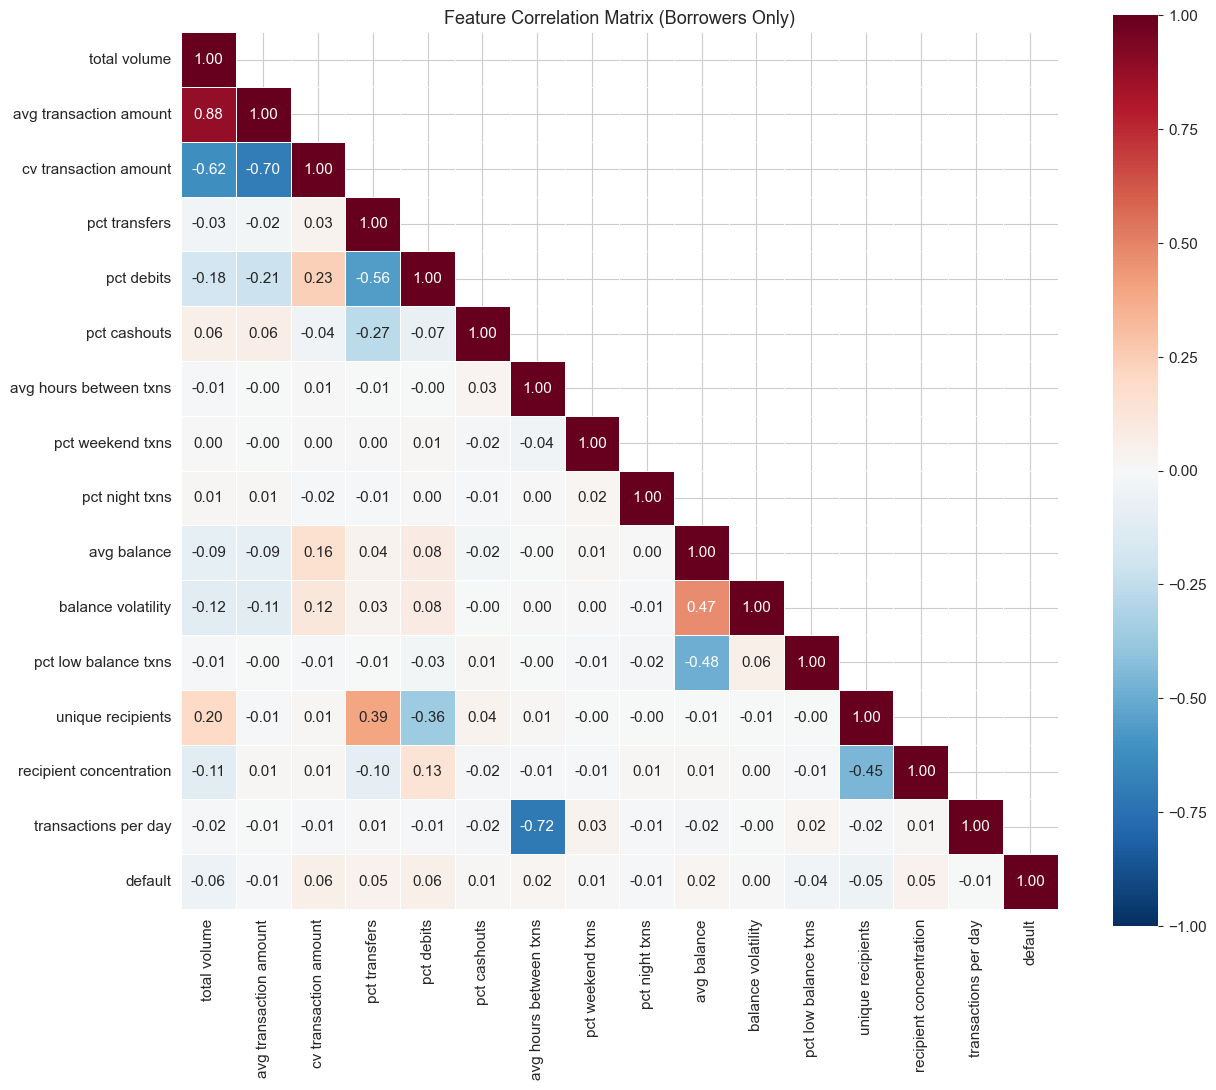

Top 10 features by |correlation| with default:
pct_debits                 0.0617
cv_transaction_amount      0.0563
total_volume              -0.0555
unique_recipients         -0.0541
pct_transfers              0.0467
recipient_concentration    0.0452
pct_low_balance_txns      -0.0388
avg_balance                0.0229
avg_hours_between_txns     0.0192
avg_transaction_amount    -0.0146


In [19]:
borrower_data = users[users['credit_risk_label'] != -1].copy()
borrower_data['default'] = (borrower_data['credit_risk_label'] == 2).astype(int)

focus_features = [
    'total_volume', 'avg_transaction_amount', 'cv_transaction_amount',
    'pct_transfers', 'pct_debits', 'pct_cashouts',
    'avg_hours_between_txns', 'pct_weekend_txns', 'pct_night_txns',
    'avg_balance', 'balance_volatility', 'pct_low_balance_txns',
    'unique_recipients', 'recipient_concentration',
    'transactions_per_day', 'default'
]

corr_data = borrower_data[focus_features].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_data, dtype=bool), k=1)
sns.heatmap(
    corr_data, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=ax, vmin=-1, vmax=1,
    xticklabels=[f.replace('_', ' ') for f in focus_features],
    yticklabels=[f.replace('_', ' ') for f in focus_features],
    square=True, linewidths=0.5
)
ax.set_title('Feature Correlation Matrix (Borrowers Only)', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with default
corr_with_default = corr_data['default'].drop('default').sort_values(key=abs, ascending=False)
print('Top 10 features by |correlation| with default:')
print(corr_with_default.head(10).round(4).to_string())

---
## Section 7: Per-Archetype Summary Statistics

Mean and standard deviation for key features, grouped by credit archetype.

In [20]:
summary_cols = [
    'obs_txn_count', 'total_volume', 'avg_transaction_amount',
    'avg_balance', 'balance_volatility', 'pct_low_balance_txns',
    'unique_recipients', 'transactions_per_day'
]

agg_mean = users.groupby('credit_archetype')[summary_cols].mean().reindex(ARCHETYPE_ORDER)
agg_std  = users.groupby('credit_archetype')[summary_cols].std().reindex(ARCHETYPE_ORDER)

# Combined mean ± std table
combined = pd.DataFrame(index=[ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER],
                         columns=[c.replace('_', ' ').title() for c in summary_cols])
for col, label in zip(summary_cols, combined.columns):
    for arch in ARCHETYPE_ORDER:
        m = agg_mean.loc[arch, col]
        s = agg_std.loc[arch, col]
        combined.loc[ARCHETYPE_LABELS[arch], label] = f'{m:.2f} ± {s:.2f}'

print('Mean ± Std Dev by Archetype')
display(combined)

Mean ± Std Dev by Archetype


,Obs Txn Count,Total Volume,Avg Transaction Amount,Avg Balance,Balance Volatility,Pct Low Balance Txns,Unique Recipients,Transactions Per Day
Non Borrower,100.11 ± 9.65,3215.50 ± 673.86,32.11 ± 5.95,136.70 ± 30.93,71.22 ± 23.98,0.02 ± 0.05,33.93 ± 4.88,4.21 ± 3.40
Responsible Borrower,106.01 ± 9.89,3392.30 ± 681.58,31.99 ± 5.62,136.31 ± 31.40,72.00 ± 24.26,0.02 ± 0.06,35.79 ± 4.94,4.36 ± 3.50
Occasional Borrower,103.30 ± 10.06,3288.66 ± 685.36,31.81 ± 5.72,137.01 ± 31.62,71.91 ± 24.86,0.02 ± 0.06,35.75 ± 4.90,4.36 ± 3.48
Risky Borrower,106.61 ± 10.80,3352.01 ± 660.56,31.43 ± 5.24,134.54 ± 31.33,71.33 ± 24.46,0.02 ± 0.06,35.33 ± 5.12,4.57 ± 3.72
Defaulter,100.79 ± 10.00,3226.03 ± 665.37,32.04 ± 5.95,140.94 ± 31.04,70.43 ± 23.62,0.01 ± 0.04,34.94 ± 4.88,4.08 ± 3.39


In [21]:
# Styled mean-only table with gradient for easy scanning
mean_table = agg_mean.copy()
mean_table.index = [ARCHETYPE_LABELS[a] for a in ARCHETYPE_ORDER]
mean_table.columns = [c.replace('_', ' ').title() for c in summary_cols]

try:
    display(mean_table.round(2).style.background_gradient(cmap='YlOrRd', axis=0).format('{:.2f}'))
except Exception:
    display(mean_table.round(2))

,Obs Txn Count,Total Volume,Avg Transaction Amount,Avg Balance,Balance Volatility,Pct Low Balance Txns,Unique Recipients,Transactions Per Day
Non Borrower,100.11,3215.50,32.11,136.70,71.22,0.02,33.93,4.21
Responsible Borrower,106.01,3392.30,31.99,136.31,72.00,0.02,35.79,4.36
Occasional Borrower,103.30,3288.66,31.81,137.01,71.91,0.02,35.75,4.36
Risky Borrower,106.61,3352.01,31.43,134.54,71.33,0.02,35.33,4.57
Defaulter,100.79,3226.03,32.04,140.94,70.43,0.01,34.94,4.08


In [22]:
print(f'Descriptive statistics complete.')
print(f'Dataset: {len(users):,} users | {len(num_cols)} numeric features | {n_txn_files:,} transaction files')
print(f'Sampled transactions: {len(txns):,} rows from {len(set(sample_ids))} users')

Descriptive statistics complete.
Dataset: 10,000 users | 29 numeric features | 10,000 transaction files
Sampled transactions: 51,556 rows from 498 users
